In [1]:
%env KMP_DUPLICATE_LIB_OK TRUE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import confusion_matrix, classification_report, adjusted_rand_score
from sklearn.decomposition import PCA
import seaborn as sns
import numpy as np
import struct
from array import array
from os.path  import join
from scipy.stats import mode
import random
import matplotlib.pyplot as plt


class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)  

env: KMP_DUPLICATE_LIB_OK=TRUE


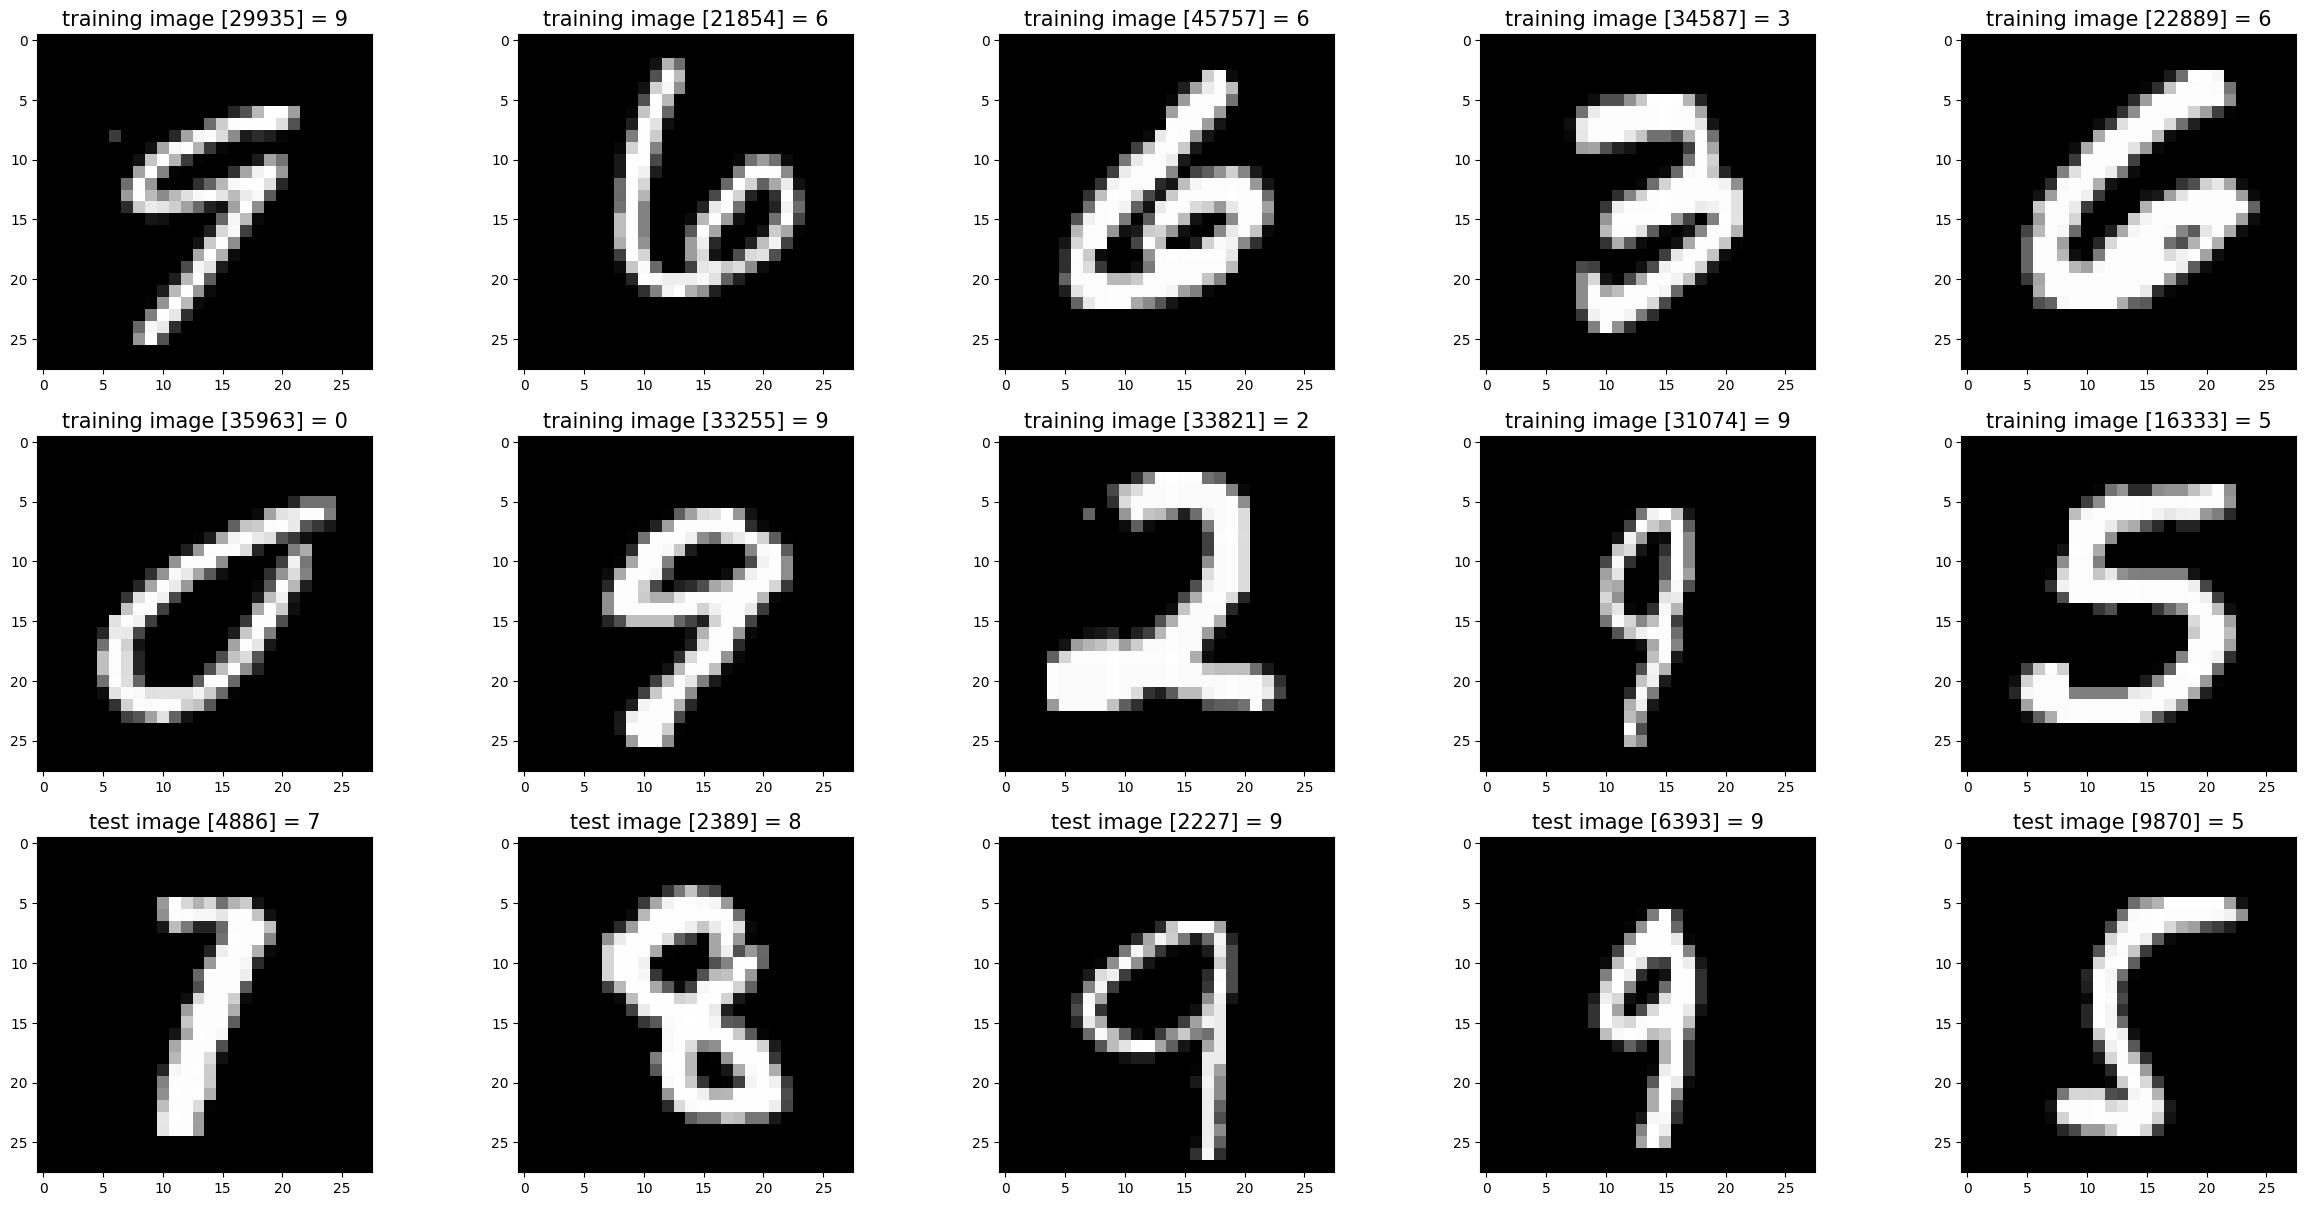

In [2]:
input_path = './'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [3]:
sample_size = 10000
train_indices = np.random.choice(len(x_train), sample_size, replace=False)
test_indices = np.random.choice(len(x_test), 2000, replace=False)

x_train_sample = np.array(x_train)[train_indices].reshape(sample_size, -1) / 255.0
y_train_sample = np.array(y_train)[train_indices]
x_test_sample = np.array(x_test)[test_indices].reshape(2000, -1) / 255.0
y_test_sample = np.array(y_test)[test_indices]

x_train_tensor = torch.tensor(x_train_sample, dtype=torch.float32).unsqueeze(1) / 255.0
y_train_tensor = torch.tensor(y_train_sample, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_sample, dtype=torch.float32).unsqueeze(1) / 255.0
y_test_tensor = torch.tensor(y_test_sample, dtype=torch.long)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [4]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.log_sigmoid = nn.LogSigmoid()
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.log_sigmoid(self.conv1(x))
        x = self.pool(x)
        x = self.log_sigmoid(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 64 * 7 * 7)
        x = self.log_sigmoid(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNet().to(device)
criterion = nn.KLDivLoss(reduction='batchmean')
optimizer = optim.RMSprop(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        
        output = model(data)
        log_probs = torch.log_softmax(output, dim=1)
        target_probs = torch.zeros_like(log_probs).scatter_(1, target.unsqueeze(1), 1)
        
        loss = criterion(log_probs, target_probs)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

Epoch 1/10, Loss: 1.1910, Accuracy: 58.48%
Epoch 2/10, Loss: 0.2566, Accuracy: 92.13%
Epoch 3/10, Loss: 0.1930, Accuracy: 94.15%
Epoch 4/10, Loss: 0.1522, Accuracy: 95.45%
Epoch 5/10, Loss: 0.1279, Accuracy: 96.17%
Epoch 6/10, Loss: 0.1095, Accuracy: 96.62%
Epoch 7/10, Loss: 0.0973, Accuracy: 97.07%
Epoch 8/10, Loss: 0.0892, Accuracy: 97.29%
Epoch 9/10, Loss: 0.0824, Accuracy: 97.51%
Epoch 10/10, Loss: 0.0779, Accuracy: 97.66%


In [6]:
model.eval()
test_correct = 0
test_total = 0
all_predictions = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        test_total += target.size(0)
        test_correct += (predicted == target).sum().item()
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_accuracy = 100. * test_correct / test_total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 98.15%


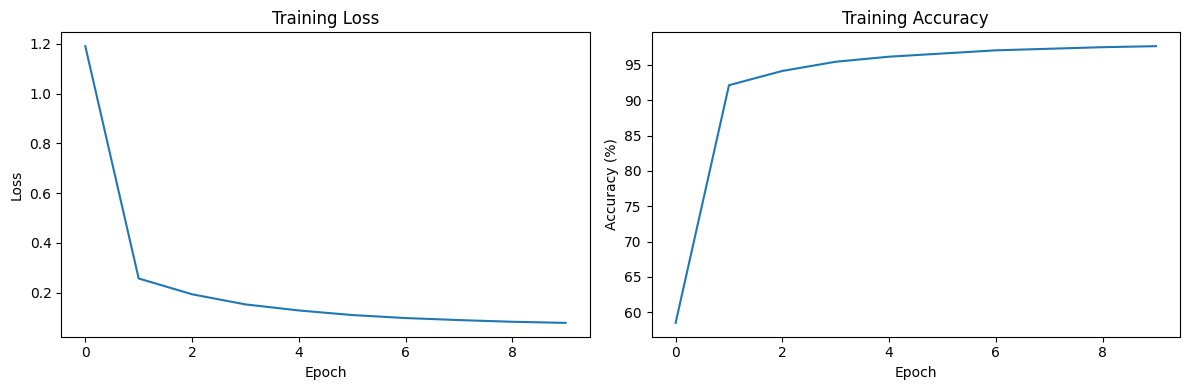

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

In [ ]:
x_train_flat = np.array(x_train).reshape(len(x_train), -1) / 255.0
x_test_flat = np.array(x_test).reshape(len(x_test), -1) / 255.0

kmeans = KMeans(n_clusters=10, random_state=42)
cluster_labels = kmeans.fit_predict(x_train_flat)

labels = np.zeros_like(cluster_labels)
for i in range(10):
    mask = (cluster_labels == i)
    if np.sum(mask) > 0:
        labels[mask] = mode(y_train[mask])[0]

cluster_accuracy = np.sum(labels == y_train) / len(y_train)
ari = adjusted_rand_score(y_train, cluster_labels)

print(f'Cluster Accuracy: {cluster_accuracy:.4f}')
print(f'Adjusted Rand Index: {ari:.4f}')

In [ ]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_train_flat)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter)
plt.title('K-Means (PCA)')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

model.eval()
with torch.no_grad():
    sample_data, sample_target = next(iter(test_loader))
    sample_data, sample_target = sample_data.to(device), sample_target.to(device)
    sample_output = model(sample_data)
    sample_pred = torch.max(sample_output, 1)[1]

axes[0, 0].imshow(sample_data[0].cpu().squeeze(), cmap='gray')
axes[0, 0].set_title(f'NN Prediction: {sample_pred[0].item()}, True: {sample_target[0].item()}')
axes[0, 0].axis('off')

cm_nn = confusion_matrix(all_targets, all_predictions)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('NN Confusion Matrix')

cm_kmeans = confusion_matrix(y_train, labels)
sns.heatmap(cm_kmeans, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('K-Means Confusion Matrix')

methods = ['NN', 'K-Means']
accuracies = [test_accuracy/100, cluster_accuracy]
axes[1, 1].bar(methods, accuracies)
axes[1, 1].set_title('Comp')
axes[1, 1].set_ylabel('Acc')

plt.tight_layout()
plt.show()